In [3]:
import pandas as pd
df = pd.read_csv("/content/Apple_stock_history.csv")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098298,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093169,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086331,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088468,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091033,0.118862,0.119420,0.118862,0.118862,73449600


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date")
df.set_index("Date",inplace=True)
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1980-12-12,0.098298,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093169,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086331,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088468,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.091033,0.118862,0.119420,0.118862,0.118862,73449600


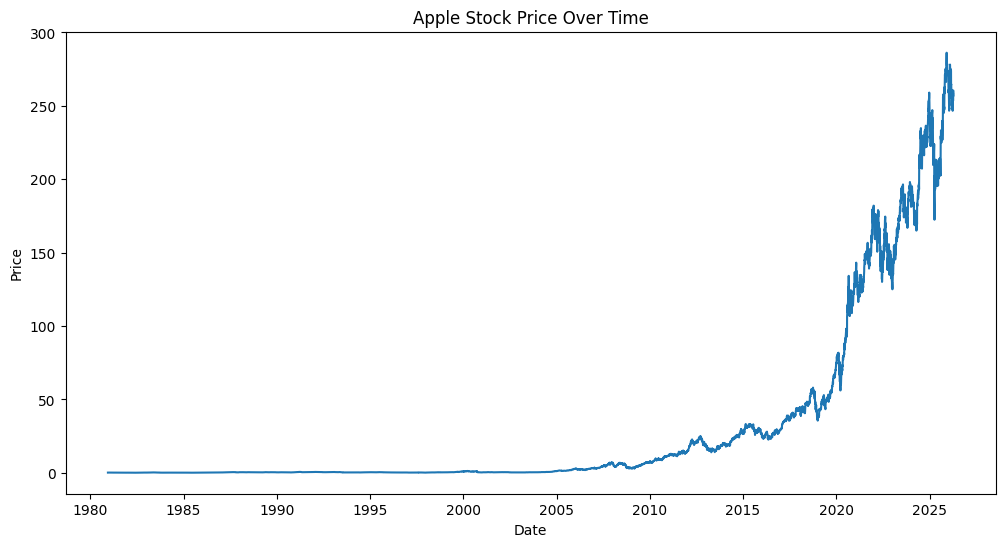

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Close"])
plt.title("Apple Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
df["Daily Return"] = df["Close"].pct_change()
df.head()

,Adj Close,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,,
1980-12-12,0.098298,0.128348,0.128906,0.128348,0.128348,469033600,NaN
1980-12-15,0.093169,0.121652,0.122210,0.121652,0.122210,175884800,-0.052171
1980-12-16,0.086331,0.112723,0.113281,0.112723,0.113281,105728000,-0.073398
1980-12-17,0.088468,0.115513,0.116071,0.115513,0.115513,86441600,0.024751
1980-12-18,0.091033,0.118862,0.119420,0.118862,0.118862,73449600,0.028992


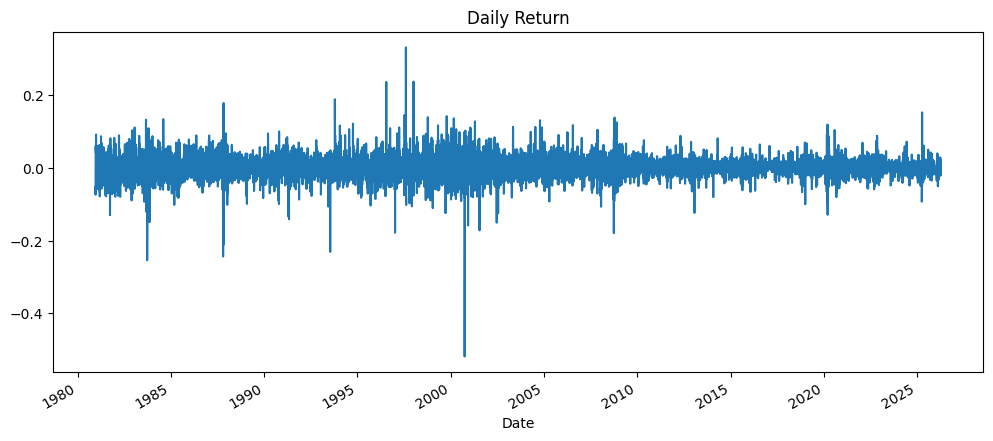

In [8]:
df["Daily Return"].plot(figsize=(12,5))
plt.title("Daily Return")
plt.show()

In [9]:
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

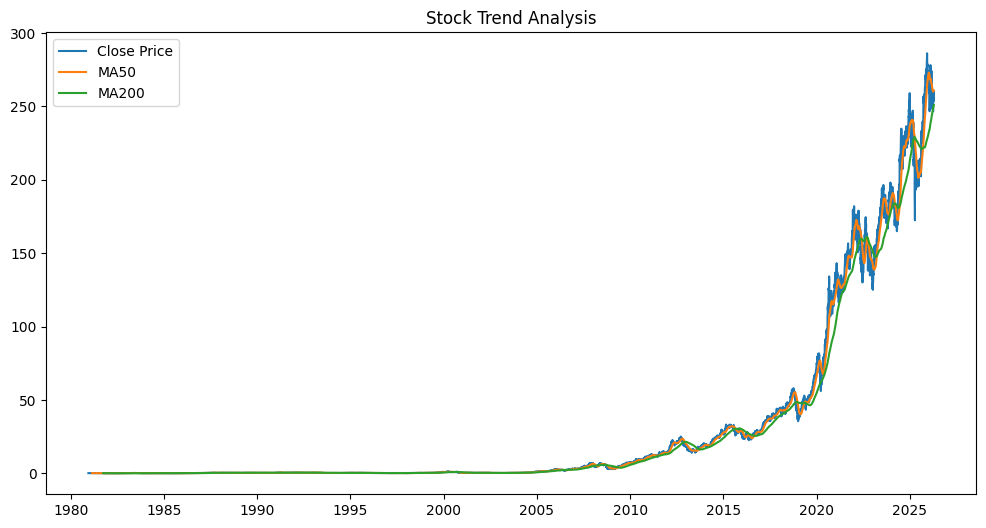

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'],label = 'Close Price')
plt.plot(df['MA50'],label = 'MA50')
plt.plot(df['MA200'],label = 'MA200')

plt.legend()
plt.title("Stock Trend Analysis")
plt.show()

In [11]:
print("Highest Price: ",df['Close'].max() )
print("Lowest Price: ",df['Close'].min() )

Highest Price:  286.19000244140625
Lowest Price:  0.0491070002317428


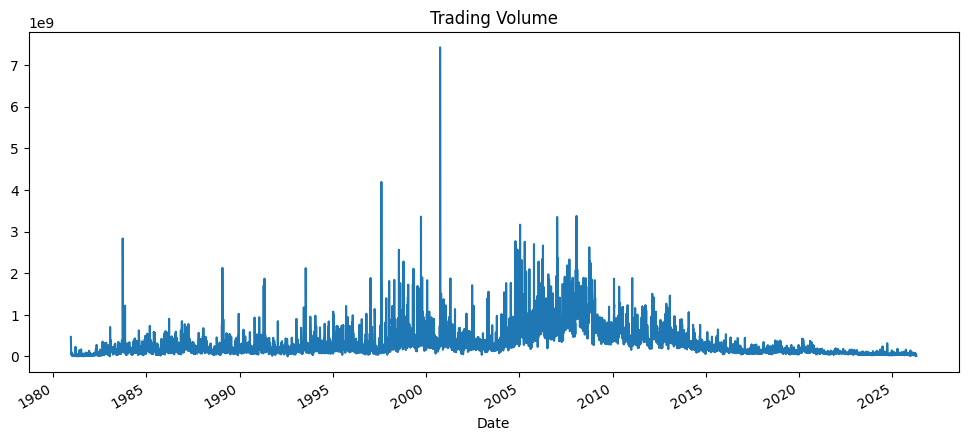

In [12]:
df['Volume'].plot(figsize=(12,5))
plt.title("Trading Volume")
plt.show()

In [14]:
before_2020 = df[df.index < "2020-01-01"]
after_2020 = df[df.index >= "2020-01-01"]

print("Before 2020 average price: ",before_2020['Close'].mean())
print("After 2020 average price: ",after_2020['Close'].mean())

Before 2020 average price:  7.736707935297191
After 2020 average price:  171.12565621501219


In [15]:
print("Volatility before 2020:", before_2020["Daily Return"].std())
print("Volatility after 2020:", after_2020["Daily Return"].std())

Volatility before 2020: 0.028633977172286364
Volatility after 2020: 0.01985785638779568


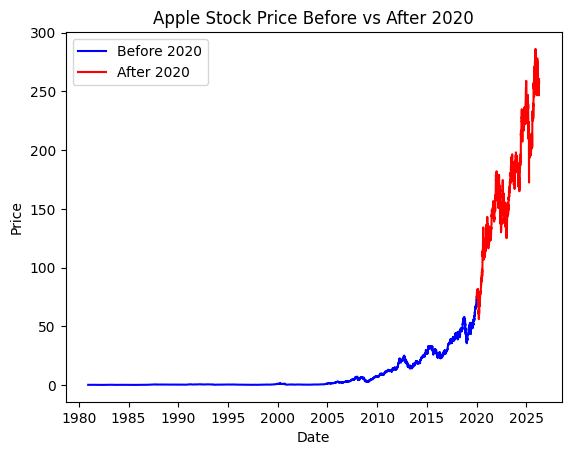

In [16]:
plt.plot(before_2020["Close"], label="Before 2020", color="blue")
plt.plot(after_2020["Close"], label="After 2020", color="red")

plt.title("Apple Stock Price Before vs After 2020")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()